# 📋 Config Quick Reference

Diese Zelle zeigt die wichtigsten Parameter aus `FIT_python/config.py` zum schnellen Nachschlagen:

## 🔧 Haupt-Parameter
- **EXPERIMENT_NAME**: `fit_notebook_final` (via `FIT_EXPERIMENT_NAME` env var)
- **GLOBAL_RANDOM_SEED**: `99`
- **TEST_SIZE**: `0.3` (30% Test, 70% Train)
- **NUM_FOLDS**: `5` (für Cross-Validation)
- **GROUP_COL**: `individual_id`
- **STRATIFY_COL**: `sex`

## 📁 Pfad-Struktur
```
EXPERIMENT_ROOT/                      # results/fit_notebook_final/
├── data/
│   ├── cleaned/                      # cfg.CLEANED_DIR
│   └── splits/                       # cfg.SPLITS_DIR
├── dataprocessing/                   # cfg.PATHS["dataprocessing"]
│   └── <species>/
│       ├── figures/
│       └── tables/
├── sex_modelling/                    # cfg.PATHS["sex_modelling"]
│   └── <species>/
│       ├── models/
│       ├── figures/
│       └── tables/
└── individual_id/                    # cfg.PATHS["individual_id"]
    └── <species>/
        ├── master_pairs.csv
        ├── figures/
        └── tables/
```

## 🎨 Farben & Mappings
- **Sex Mapping**: `{0: "Female", 1: "Male", "f": "Female", "m": "Male"}`
- **Sex Colors**: `Female: #800000` (Rot), `Male: #000080` (Blau)
- **Figure DPI**: `300` (Standard für alle Plots)

## 🔬 Pipeline-Defaults
- **Outlier Handling**: `clip` (Quantile: 0.01-0.99)
- **Scaler**: `standard` (StandardScaler)
- **Dimensionality Reduction**: `pca` (n_components=2) oder `umap`
- **Sex Model Metric**: `balanced_accuracy`

## 🐾 Spezies
```python
SPECIES_MODEL_MAP = {
    "panthera_tigris_altaica": "amur_tiger",
    "panthera_tigris_tigris": "bengal_tiger",
    "acinonyx_jubatus": "cheetah",
    "lutra_lutra": "eurasian_otter",
    "tapirus_terrestris": "lowlandtapir",
    "puma_concolor": "mountain_lion",
    "ceratotherium_simum": "white_rhino",
}
```

**Hinweis**: Vollständige Config in [src/FIT_python/config.py](../src/FIT_python/config.py)

Introduction and general goal of this study:
The Footprint Identification Technique (FIT) is a method used to identify individual animals based on their footprints. It also enables the extraction and modeling of additional information such as the sex of the animal that left the footprint.
FIT is currently available as a free add-in for the JMP statistical software and has been custom-tailored for several endangered species. The aim of this dissertation was to establish FIT for the Eurasian otter and benchmark its classification capabilities against those previously published for other species.
This initial analysis was conducted using JMP. However, throughout the workflow, several limitations became evident—particularly regarding automation capabilities for experiments involving modified workflows and the reproducibility of annotated images.
Due to these limitations, the decision was made to transfer the methodology to a Python package, which will be open source and publicly available once the results are published.
The aim of this package is to
1.	replicate the original workflow and analyses of the JMP add-in
2.	optimize the approach for automation
3.	provide flexibility in terms of methodological components and explore whether modifications at various analysis stages lead to improved FIT models.
Although the main aim remained to develop this technique for Eurasian otters all experiments where conducted on several datasets so that the results for otters where always benchmarked with other established species. The following paragraph describes the methodology and the graphs and tables generated at each step.



In [1]:
from pathlib import Path
import sys, importlib
import os
import shutil

# ---------------------------------------------------------------------
# 1. Project Root
# ---------------------------------------------------------------------
# Für Notebooks: gehe eine Ebene hoch (von notebooks -> Projektwurzel)
if "__file__" in globals():
    root = Path(__file__).resolve().parent.parent
else:
    root = Path().resolve().parent

# Quellcode einbinden
src = root / "src"
sys.path.insert(0, str(src))

# ---------------------------------------------------------------------
# 2. Set Experiment Name BEFORE importing config
# ---------------------------------------------------------------------
os.environ["FIT_EXPERIMENT_NAME"] = "fit_notebook_final_2026_123"

# ---------------------------------------------------------------------
# 3. Import config (setzt nun results/<experiment_name>/ als Root)
# ---------------------------------------------------------------------
import FIT_python.config as cfg
importlib.reload(cfg)  # recompute paths after import

# ---------------------------------------------------------------------
# 4. Experiment Directory
# ---------------------------------------------------------------------
EXP_DIR = cfg.EXPERIMENT_ROOT
EXP_DIR.mkdir(parents=True, exist_ok=True)

print("Project root directory:", root)
print("Experiment directory:", EXP_DIR)
print("RAW data directory:", cfg.RAW_DIR)

# ---------------------------------------------------------------------
# 5. Cache-Ordner löschen (alle __pycache__ unterhalb von DATA_DIR)
# ---------------------------------------------------------------------
for pycache in cfg.DATA_DIR.rglob("__pycache__"):
    shutil.rmtree(pycache)
    print(f"🗑 Cache entfernt: {pycache}")


[CONFIG] Initial config saved to: config_logs\config_20260120_173745_4617c936_initial.json
Project root directory: C:\otter_fit\FIT_package
Experiment directory: c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026_123
RAW data directory: C:\otter_fit\FIT_package\data\raw


Before any train/test splits, a summary table of all analyzed datasets is generated and saved.
Columns:
• Species (Cummonn amen & Latin name) @ gtp you might need a helper dictionary here to consistently right common name and latin name (you can map species labes from the dataset to match style for a research paper)
• No. of footprints [Number of obeseravtions in df • 
No. of known individuals df[individual_id] (after renaming from the original animal coulum check load and split utils)

 No. of trails ( count df[“trails].unique
• No. of measurements ( count number of feature colums Measurements consist of any columns beginning with “V”, “Area”, “dist”, “ang” or “T”, depending on the dataset. Use existing data-loading scripts and feature definitions where possible. Be flexible for groß und kleinschreibung depindig whether data sanatize is already conducted here or not)


In [2]:
from FIT_python.data_split_and_summary.data_import_wrapper import DataImportWrapper
from FIT_python import config as cfg

# Clean all datasets and generate correlation plots
# Note: Correlation plots are automatically saved to:
#   <EXPERIMENT_ROOT>/dataprocessing/<species>/figures/feature_correlations/
wrapper = DataImportWrapper()
result = wrapper.clean_all(generate_histograms=cfg.CONFIG["data_split_and_summary"]["generate_histograms"])

if result == 0:
    print("\n✅ All datasets cleaned and correlation plots saved successfully")
    print(f"📊 Correlation plots location: {cfg.PATHS['dataprocessing']}/<species>/figures/feature_correlations/")
else:
    print("\n⚠️ Some issues occurred during cleaning - check warnings above")

Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned cheetah: shape=(781, 141)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned Eurasian_Otter: shape=(628, 214)
[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[REPORT] cleaned Giant_Panda: shape=(523, 129)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned Lowlandtapir: shape=(426, 126)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned Mountain_Lion: shape=(535, 138)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[REPORT] cleaned White_Rhino: shape=(1273, 117)
[WARN] Insufficient features for correlation plot (found 0), skipping.
[SUCCESS] clean_all completed.

✅ All dat

### Wichtige Hinweise zur Datenaufbereitung

Die `clean_all()` Methode führt folgende Schritte aus:
1. **Lädt Rohdaten** aus `RAW_DIR`
2. **Bereinigt Labels** (Individual IDs, Sex, etc.)
3. **Speichert Parquet-Dateien** in `CLEANED_DIR`
4. **Generiert Correlation-Plots** für jede Spezies (Feature-Gruppen: distance, angle, triangles)

**Robustheit bei fehlenden Features:**
- Falls eine Spezies <2 Features einer Kategorie hat, wird ein Platzhalter angezeigt statt eines Fehlers
- Warnung im Log: `[WARN] correlation plot failed for <species>: ...`
- Plots werden immer gespeichert unter: `<experiment_root>/dataprocessing/<species>/figures/feature_correlations/`

**DPI-Standard:** Alle Plots werden mit **DPI=300** für Publikationsqualität gespeichert.

Overview generation of Datasets in experiment

In [3]:
from FIT_python.data_split_and_summary.dataset_summary import generate_dataset_overview

# Generate overview with summary statistics for all species
# Note: Last row will contain totals across all species
overview_df = generate_dataset_overview(cfg.RAW_DIR, EXP_DIR/'dataset_overview.parquet', reuse=cfg.CONFIG["data_split_and_summary"]["reuse_overview"])
overview_df

Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Datasets:   0%|          | 0/8 [00:00<?, ?it/s]

,Species,No. of footprints,No. of known individuals,No. of female individuals,No. of male individuals,No. of trails,No. of measurements
0,Amur Tiger (Panthera tigris altaica),605,44,23,21,86,128
1,Bengal Tiger (Panthera tigris tigris),586,40,15,19,87,128
2,Cheetah (Acinonyx jubatus),781,38,16,22,110,135
3,Eurasian Otter (Lutra lutra),628,42,20,21,80,205
4,Giant Panda (Ailuropoda melanoleuca),523,42,22,20,77,122
5,Lowland Tapir (Tapirus terrestris),426,37,19,17,64,90
6,Mountain Lion (Puma concolor),535,35,19,16,78,131
7,White Rhinoceros (Ceratotherium simum),1273,41,21,20,154,104
8,All Species Total,5357,319,155,156,736,1043


Training and Test splits and inference splits
For both sex‐classification and individual‐identification models, the captive dataset of known individuals was randomly divided into training and validation subsets using a script‐based, group‐stratified sampling procedure with a fixed random seed to ensure reproducibility. Stratification guaranteed an even sex ratio across both splits, while grouping by animal prevented any overlap of individuals between training and testset.  Additional Validation folds were created and assigned and later used for hyperparameter optimization.
For the Otters a custom script for generating the folds was used making sure, that dna validated field prints only appeared in the testset, additionally since we had a set of prints in Sand and a set of prints in mud available we made sure that an equal number of individuals of both sexes are present in the testset. Train test splits needs to be executed here as it includes data cleaning steps that otherwise cause errors in the data exploration and visualisations functions that technically come beforehand in the dissertations


Loading:   0%|          | 0/8 [00:00<?, ?it/s]

Cleaning:   0%|          | 0/8 [00:00<?, ?it/s]

Converting:   0%|          | 0/8 [00:00<?, ?it/s]

Splitting datasets:   0%|          | 0/8 [00:00<?, ?it/s]

✔️ Fold-Spalte in amur_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    100
1     99
2     91
3     97
4    100

📊 amur_tiger – train – 487 Zeilen | 35 Individuen | 70 Trails
sex
f    265
m    222

📊 amur_tiger – test – 118 Zeilen | 9 Individuen | 16 Trails
sex
f    79
m    39

📊 amur_tiger – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ amur_tiger gespeichert (parquet)
✔️ Fold-Spalte in bengal_tiger schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    123
1    102
2     61
3     83
4     70

📊 bengal_tiger – train – 439 Zeilen | 27 Individuen | 64 Trails
sex
m    254
f    185

📊 bengal_tiger – test – 109 Zeilen | 7 Individuen | 16 Trails
sex
m    74
f    35

📊 bengal_tiger – inference – 38 Zeilen | 6 Individuen | 7 Trails
sex
unknown    38

✅ bengal_tiger gespeichert (parquet)
✔️ Fold-Spalte in cheetah schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    

C:\otter_fit\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:244: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\otter_fit\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:244: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids



📊 eurasian_otter – test – 152 Zeilen | 14 Individuen | 19 Trails
sex
f    86
m    66

📊 eurasian_otter – inference – 81 Zeilen | 1 Individuen | 8 Trails
sex
unknown    81

✅ eurasian_otter gespeichert (parquet)
✔️ Fold-Spalte in giant_panda schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    84
1    78
2    74
3    70
4    98

📊 giant_panda – train – 404 Zeilen | 33 Individuen | 59 Trails
sex
f    251
m    153

📊 giant_panda – test – 119 Zeilen | 9 Individuen | 18 Trails
sex
m    69
f    50

📊 giant_panda – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ giant_panda gespeichert (parquet)
✔️ Fold-Spalte in lowlandtapir schon gesetzt – keine erneute Zuweisung.
✅ Fold-Methode verwendet: predefined
Fold
0    60
1    56
2    49
3    58
4    77

📊 lowlandtapir – train – 300 Zeilen | 28 Individuen | 46 Trails
sex
m    157
f    143

📊 lowlandtapir – test – 122 Zeilen | 8 Individuen | 17 Trails
sex
m    73
f    49

📊 lowlandtapir – inference –

Datasets:   0%|          | 0/1 [00:00<?, ?it/s]

Splits:   0%|          | 0/3 [00:00<?, ?it/s]


[DEBUG] compute_summary called for eurasian_otter/inference, df shape = (81, 214)
[DEBUG] ds_label = eurasian_otter Inference
[DEBUG] species column raw: species exists? True, Species exists? False
[DEBUG] using 'species' column
[DEBUG] species_vals = ['lutra_lutra']
[DEBUG] species_code = lutra lutra
[DEBUG] sex value counts:
sex
Unknown    81
Name: count, dtype: int64
[DEBUG] has_dataorigin = True, dataorigins = ['Fieldprints Portugal']
[DEBUG] dataorigin=Fieldprints Portugal, sex=Female, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] dataorigin=Fieldprints Portugal, sex=Male, subset shape = (0, 214)
[DEBUG]  n_fp=0, n_ind=0, n_tr=0
[DEBUG]   no individuals, setting means and sds to 0
[DEBUG] dataorigin=Fieldprints Portugal, sex=Unknown, subset shape = (81, 214)
[DEBUG]  n_fp=81, n_ind=1, n_tr=8
[DEBUG]   fp_per_ind summary: mean=81.0, sd=0.0
[DEBUG]   tr_per_ind summary: mean=8.0, sd=0.0
[DEBUG] Returning summar

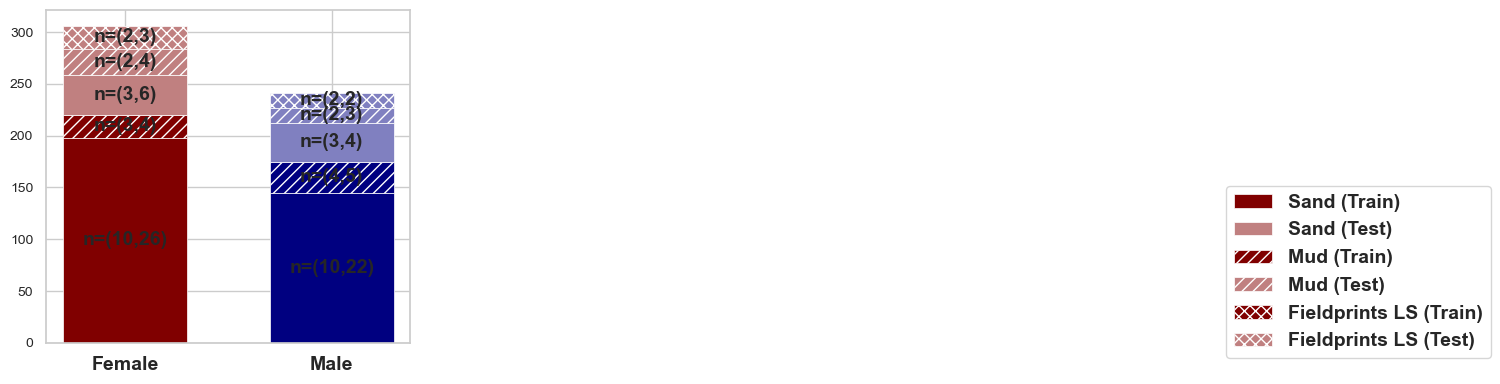

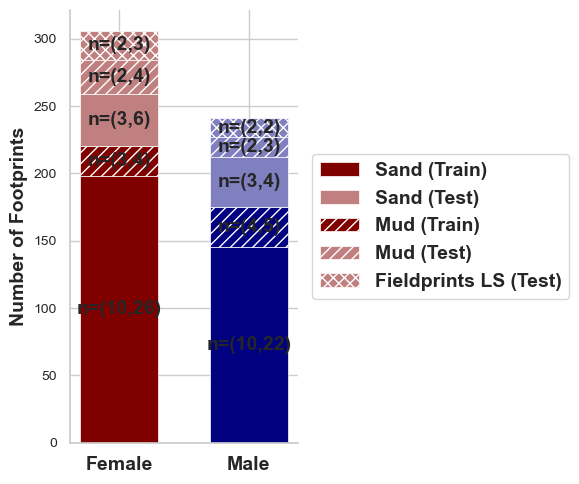

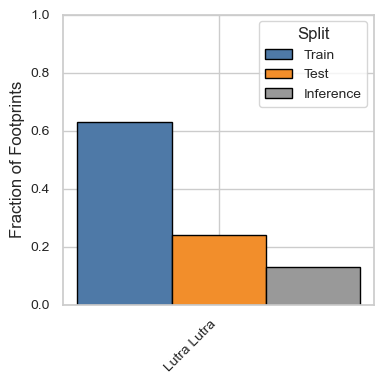

In [4]:
from FIT_python import config
from FIT_python.data_split_and_summary.summary_data_wrapper import run_summary
from FIT_python.data_split_and_summary.datasplit_and_summary_wraper import SplitWrapper

species = "eurasian_otter"
SplitWrapper().split_all(reuse_splits=config.CONFIG["data_split_and_summary"]["reuse_splits"])

run_summary(config.SPLITS_DIR / species, species)

Data Exploration (This step is performed exclusively on the otter data to keep the number of plots manageable.)
With over two hundred measurements extracted from just 11 unique landmarks, we anticipate high correlation among features. Previous FIT publications have shown that using many measurements aids individual identification. However, when the number of measurements far exceeds the number of landmarks, strong correlations between individual measurements emerge.
1.	A correlation matrix (Distances, Angles, Areas) is visualized (see “Correlation Matrix for Eurasian Otters”).
2.	We examine the top four univariate features with the highest separation power for the targets “sex” and “individual_id” on the full otter dataset.
3.	We generate two supervised UMAP embeddings—for “sex” and for “individual_id”—using fivefold cross-validation. Note that these embeddings are for visualization only; all modeling steps described later adhere to a stricter split regime.


In [5]:
from FIT_python.utils.paths import get_species_paths
from FIT_python.Visualisations.plots_utils import plot_feature_correlation_matrix, plot_individual_boxplots_2x1
from FIT_python import config as cfg
import pandas as pd
from FIT_python import config as cfg
from IPython.display import Image, display
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib.lines import Line2D
from sklearn.feature_selection import f_classif
from sklearn.preprocessing import LabelEncoder
from IPython.display import display, Markdown
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols


otter_df = pd.read_parquet(cfg.CLEANED_DIR / "Eurasian_Otter.parquet")


species = "eurasian_otter"

# get paths managed by the config (e.g. in dataprocessing/eurasian_otter/figures)
paths = get_species_paths(species, section="dataprocessing")
fig_dir = paths["figures"]          # directory already created by get_species_paths
fig_path = plot_feature_correlation_matrix(otter_df, fig_dir)  # figure saved here

feature_cols = get_feature_cols(otter_df)
# --- Aufruf ---
plot_individual_boxplots_2x1(
    df=otter_df,
    fig_dir=fig_dir,
    filename="individual_boxplots_2x1.png",
    feature_cols=feature_cols
)


[CAPTION] 2×2 panel of correlation heatmaps a)–d) with a single external colorbar.
[CAPTION] Boxplots of ['dist10_14', 't2_3_5'] grouped by individual


(WindowsPath('c:/otter_fit/FIT_package/notebooks/results/fit_notebook_final_2026_123/dataprocessing/eurasian_otter/figures/individual_boxplots_2x1.png'),
 ['dist10_14', 't2_3_5'])

Visualisierung mit Umap alle Otter

KeyError: 'UMAP1'

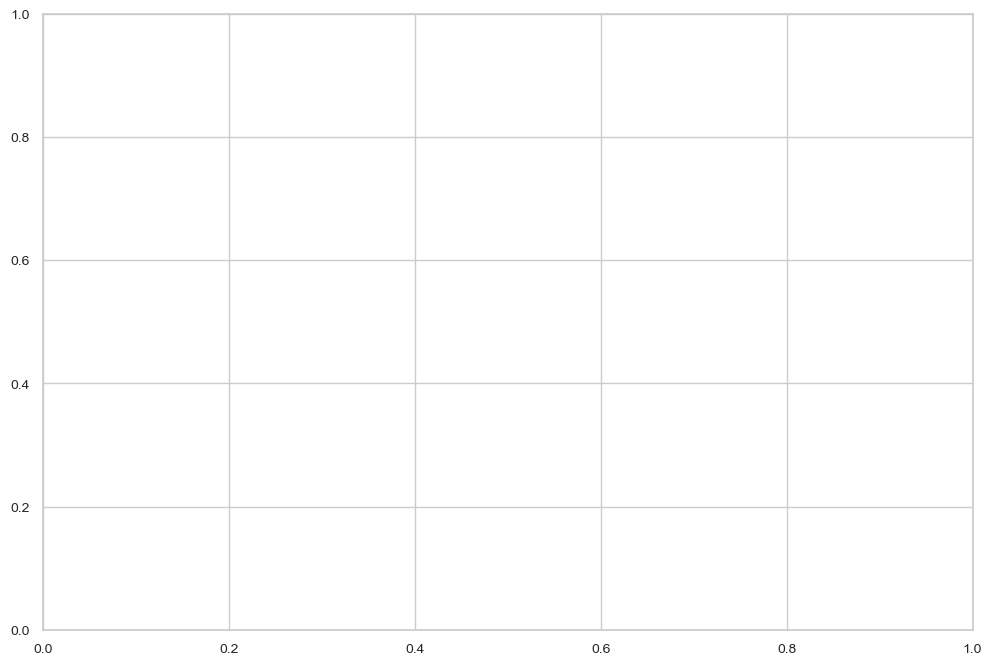

In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import itertools
from matplotlib.lines import Line2D
from FIT_python.data_split_and_summary.data_import_utils import get_feature_cols
from FIT_python.data_split_and_summary.transform_utils import convert_numeric
from FIT_python.general_pipeline_steps.dimensionality_reduction_wrapper import DimensionalityReducerTransformer
from FIT_python.utils.paths import get_species_paths
from FIT_python import config as cfg


# Hilfsfunktion für Farbaufhellung (aus config.py)
def lighten_color(color: str, amount: float) -> str:
    """Lighten a hex color by the given amount (0.0 = no change, 1.0 = white)."""
    color = color.lstrip("#")
    r = int(color[0:2], 16) / 255
    g = int(color[2:4], 16) / 255
    b = int(color[4:6], 16) / 255
    r = round((r + (1 - r) * amount) * 255)
    g = round((g + (1 - g) * amount) * 255)
    b = round((b + (1 - b) * amount) * 255)
    return f"#{r:02x}{g:02x}{b:02x}"


# --------------------------------
# Embedding erzeugen
# --------------------------------
# Nur gewünschte Dataorigins filtern
otter_df = otter_df[otter_df['dataorigin'].isin([
    'Vetrecova et al', 'Own Data Collection', 'Fieldprints Lower Saxony'
])]
species = "eurasian_otter"

# Features bestimmen und numerisch umwandeln
features = get_feature_cols(otter_df)
otter_df = convert_numeric(otter_df, features)
X = otter_df[features].astype(float)

# supervised UMAP mit Individual-ID und festem Seed aus CONFIG
dr = DimensionalityReducerTransformer(
    method=cfg.CONFIG["general_pipeline_steps"]["dim_reducer_defaults"]["method"],
    supervised=cfg.CONFIG["general_pipeline_steps"]["dim_reducer_defaults"]["supervised"],
    random_state=cfg.GLOBAL_RANDOM_SEED
)
emb = dr.fit_transform(X, otter_df['individual_id'])

# DataFrame mit Embedding und Metadaten
emb_df = pd.DataFrame(emb, index=otter_df.index, columns=dr.get_feature_names_out())
emb_df = emb_df.assign(
    individual_id=otter_df['individual_id'],
    sex_mapped=otter_df['sex'].map({'f':'Female', 'F':'Female', 0:'Female',
                                    'm':'Male', 'M':'Male', 1:'Male'}),
    dataorigin=otter_df['dataorigin']
)

# Marker-Liste für viele Individuen
markers = ['o', 's', '^', 'v', '<', '>', 'P', 'X', 'D', '*', '+', 'x', '|', '_',
           '1', '2', '3', '4', '8', 'p', 'H', 'h', 'd', '.', ',']
marker_cycle = itertools.cycle(markers)
unique_individuals = emb_df['individual_id'].unique()
marker_map = {ind: next(marker_cycle) for ind in unique_individuals}

# Farben aus Config verwenden (wie in Boxplots)
sex_colors = cfg.SEX_COLORS  # {"Female": "#800000", "Male": "#000080"}
dataset_shades = cfg.DATASET_COLOR_SHADES  # {"Own Data Collection": 0.0, "Vetrecova et al": 0.2, "Fieldprints Lower Saxony": 0.4}

# Farbpalette erstellen mit dataset-spezifischen Schattierungen
sex_palette = {
    sex: {
        origin: lighten_color(color, dataset_shades[origin])
        for origin in dataset_shades
    }
    for sex, color in sex_colors.items()
    if sex in ["Female", "Male"]
}

# Farbe zuweisen basierend auf Sex und Data Origin
def assign_color(row):
    return sex_palette[row['sex_mapped']][row['dataorigin']]

emb_df['color'] = emb_df.apply(assign_color, axis=1)

# Plot erstellen mit CONFIG-Parametern
figsize = cfg.CONFIG["visualisation"]["figure_sizes"]["umap_plot"]
axis_fontsize = cfg.CONFIG["visualisation"]["font_sizes"]["axis_label"]
legend_fontsize = cfg.CONFIG["visualisation"]["font_sizes"]["legend"]

fig, ax = plt.subplots(figsize=figsize)
for (sex, origin), group in emb_df.groupby(['sex_mapped', 'dataorigin']):
    for ind, subgroup in group.groupby('individual_id'):
        ax.scatter(
            subgroup['UMAP1'], subgroup['UMAP2'],
            c=subgroup['color'],
            marker=marker_map[ind],
            s=130,
            alpha=0.9,
            edgecolor='black',
            linewidth=0.4
        )

# Achsenbeschriftungen
ax.set_xlabel("UMAP Dimension 1", fontsize=axis_fontsize)
ax.set_ylabel("UMAP Dimension 2", fontsize=axis_fontsize)

# Legende mit allen Sex/Origin Kombinationen
legend_elements = []
origin_order = list(dataset_shades.keys())
for sex in ["Female", "Male"]:
    for origin in origin_order:
        legend_elements.append(Line2D(
            [0], [0], marker='o', color='w', label=f"{sex}, {origin}",
            markerfacecolor=sex_palette[sex][origin], markersize=10, markeredgecolor='black'
        ))

ax.legend(handles=legend_elements, title="Sex and Data Origin", fontsize=legend_fontsize, loc='best')

# Speichern mit CONFIG DPI
species = "eurasian_otter"
fig_dir = get_species_paths(species, section="dataprocessing")["figures"]
fig_path = fig_dir / "umap_individuals_sex_origin_shaded_by_dataset.png"
plt.savefig(fig_path, dpi=cfg.CONFIG["visualisation"]["dpi"], bbox_inches='tight')
plt.show()

print(f"✅ UMAP plot saved: {fig_path}")

Training sex Model

c:\Users\Frede\miniconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\preprocessing\_label.py:302: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  self.y_type_ = type_of_target(y, input_name="y")
c:\Users\Frede\miniconda3\envs\FIT_python_conda_env\Lib\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples.
  ys_types = set(type_of_target(x) for x in ys)
C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\search.py:170: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df_all = pd.read_csv(all_csv).apply(pd.to_numeric, errors="ignore")
C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\search.py:171: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explici

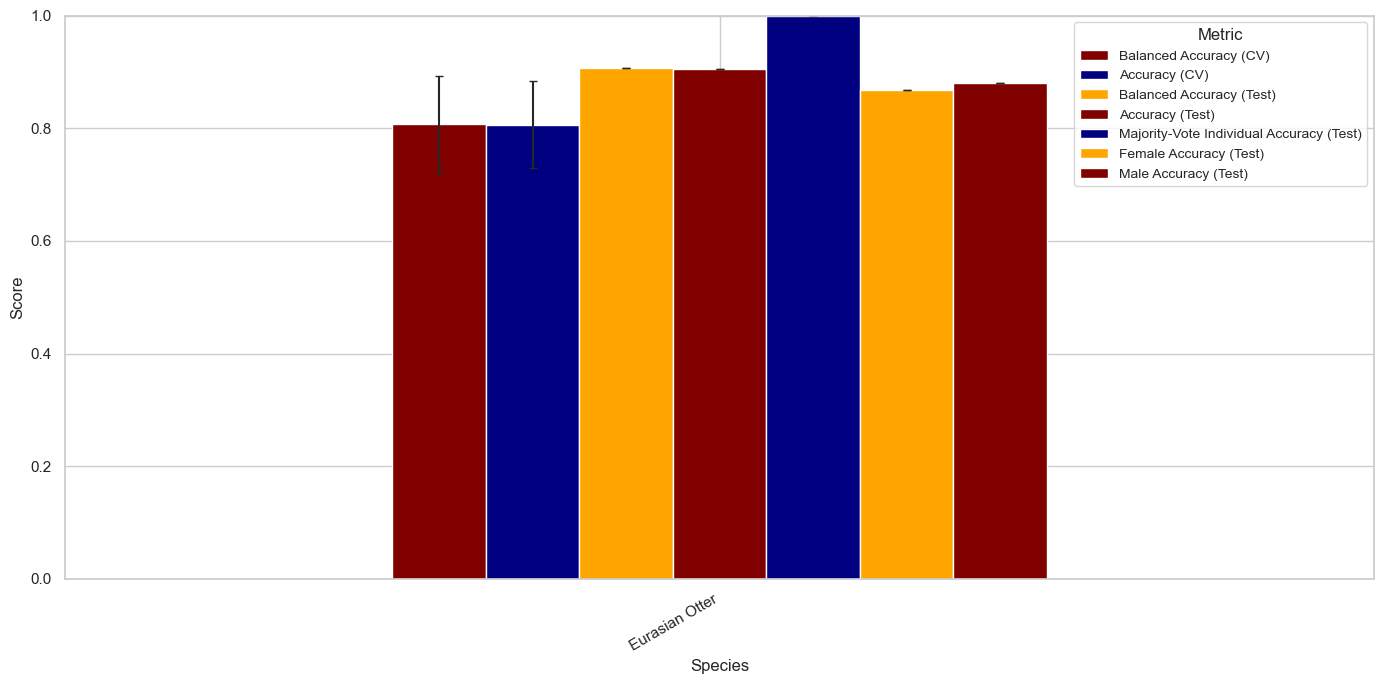

In [ ]:
# Plot
ax = (benchmark_df
      .set_index("Species")[plot_cols]
      .plot(kind="bar", 
            figsize=cfg.CONFIG["visualisation"]["figure_sizes"]["benchmark_bar"], 
            yerr=yerr_df.T.values, 
            capsize=cfg.CONFIG["visualisation"]["error_bar_capsize"]))

ax.set_ylabel("Score", fontsize=cfg.CONFIG["visualisation"]["font_sizes"]["axis_label"])
ax.set_xlabel("Species", fontsize=cfg.CONFIG["visualisation"]["font_sizes"]["axis_label"])
ax.legend(title="Metric", fontsize=cfg.CONFIG["visualisation"]["font_sizes"]["legend"])
ax.set_ylim(0, 1)
plt.xticks(rotation=30, ha="right", fontsize=cfg.CONFIG["visualisation"]["font_sizes"]["tick_label"])
plt.yticks(fontsize=cfg.CONFIG["visualisation"]["font_sizes"]["tick_label"])
plt.tight_layout()
plt.savefig(benchmark_dir / "benchmark_summary_best_test_plot.png", dpi=cfg.CONFIG["visualisation"]["dpi"])
plt.show()


📊 Starte Plotgruppe: DEIN_METRIC_KEY


C:\Users\Frede\AppData\Local\Temp\ipykernel_9988\192525730.py:87: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_all["pred_sex"] = df_all["pred_sex"].replace(sex_mapping)


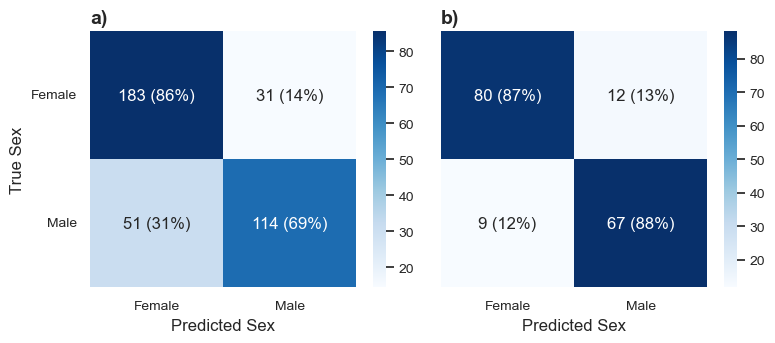

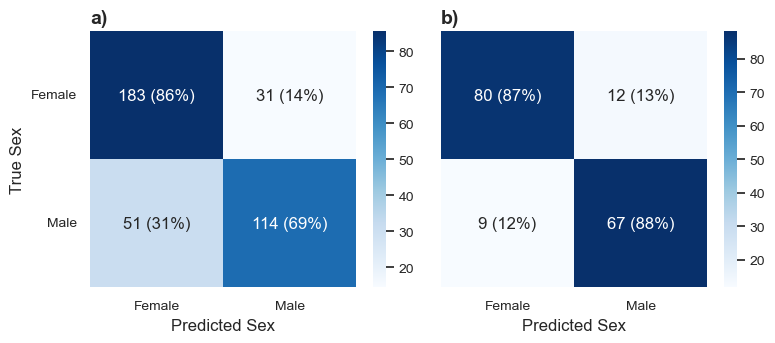

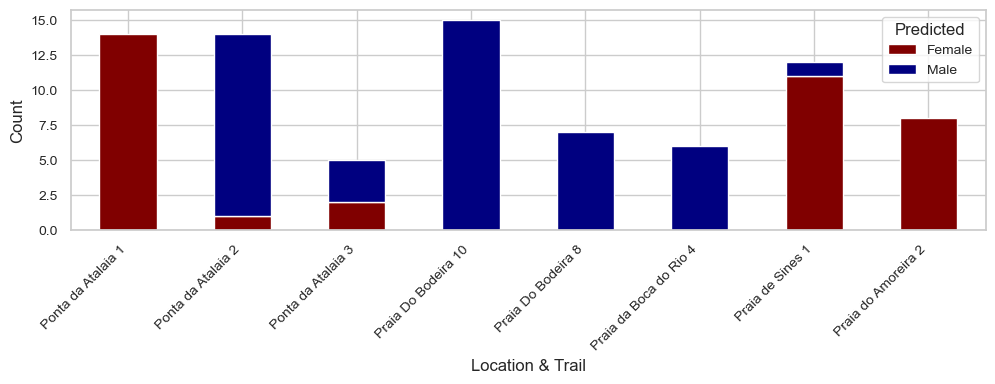

C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(na

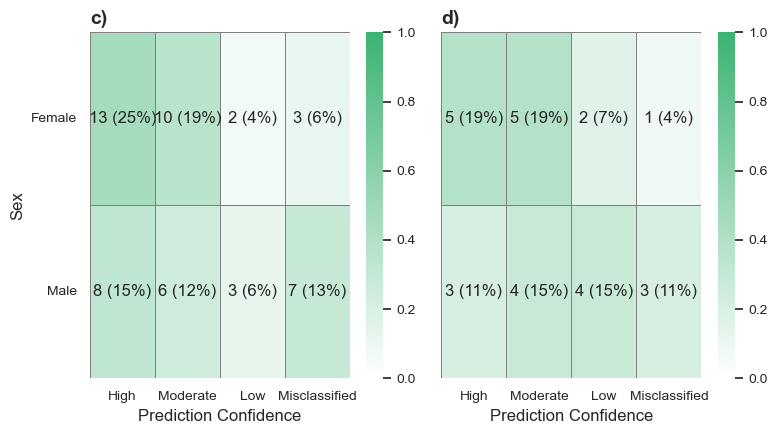

C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(name="Class")
C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:582: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  acc = df_plot.groupby(cols).apply(classify_majority).reset_index(na

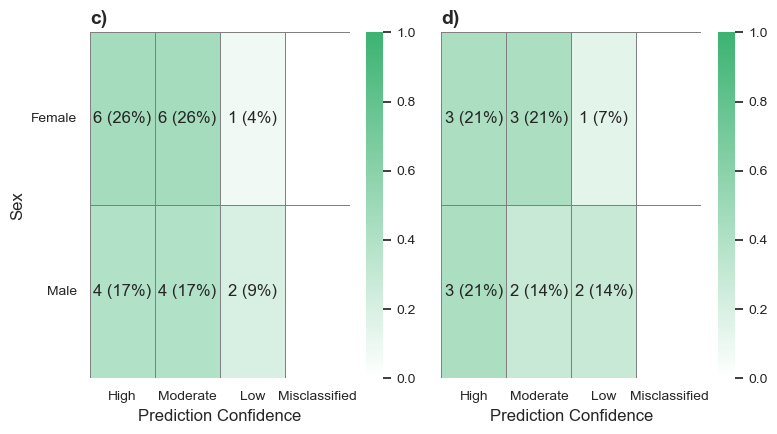

C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


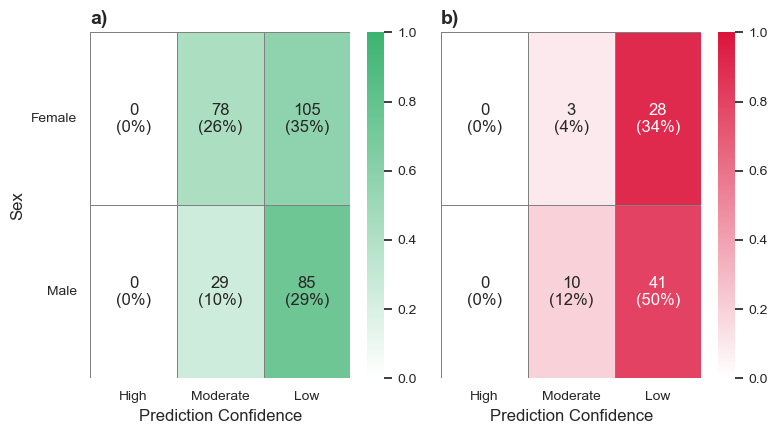

C:\otter_fit\FIT_package\src\FIT_python\pipeline_sex\sex_predict_and_visualisation.py:673: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return block.applymap(lambda x: (f"{int(x)}\n({int(round(x / total * 100))}%)" if total > 0 else "0\n(0%)"))


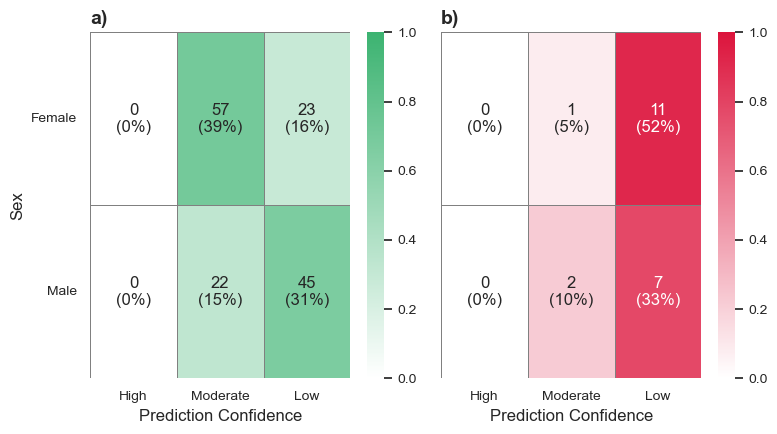

[CAPTION] Predicted male probability for pred train
[CAPTION] Predicted male probability for pred test
✅ Ergebnisse für balanced_accuracy gespeichert in c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026\Sex_plots\balanced_accuracy


In [ ]:
    fig.savefig(out_dir / f"prediction_histogram_{metric_key}.png", dpi=cfg.CONFIG["visualisation"]["dpi"])
    plt.close()

In [ ]:
                    n_components=2,
                    scaler_methods="standard",
                    use_sexmodel_prediction=use_sex,
                    n_jobs=cfg.CONFIG["general_pipeline_steps"]["n_jobs"],
                )

✅ Using base_dir: c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026\data\splits
✅ Saving results to: c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026\individual_id

##### amur_tiger  →  amur_tiger #####
📊 Datensatzgrößen – Train: 484, Test: 121, Inference: 0


FileNotFoundError: No model found at c:\otter_fit\FIT_package\notebooks\results\fit_notebook_final_2026\sex_modelling\amur_tiger\models\balanced_accuracy\amur_tiger.joblib

In [ ]:
# %% [markdown]
# --- Fold-Nachtrag für alle Spezies-Master-Pairs ---
# Liest alle *_master_pairs.csv, ergänzt fold-Infos aus train.parquet
# und speichert eine kombinierte CSV "ALL_species_master_pairs_with_folds.csv"

import pandas as pd
from pathlib import Path
from FIT_python import config as cfg

base_dir = cfg.PATHS["individual_id"]
splits_dir = cfg.PATHS["splits"]  # z.B. notebooks/results/fit_notebook_final/data/splits

all_species_dfs = []

for sp_dir in sorted(base_dir.iterdir()):
    if not sp_dir.is_dir():
        continue
    species = sp_dir.name
    master_fp = sp_dir / f"{species}_master_pairs.csv"
    if not master_fp.exists():
        print(f"⚠️ {species}: Master-Pairs fehlt, überspringe")
        continue

    df_pairs = pd.read_csv(master_fp)
    if "species" not in df_pairs.columns:
        df_pairs["species"] = species

    # Falls fold-Spalte existiert -> normalisieren
    if "fold" not in df_pairs.columns:
        df_pairs["fold"] = pd.NA

    # Nur ergänzen, wenn origin != test und fold NaN ist
    mask_missing = df_pairs["fold"].isna() & (df_pairs.get("origin") != "test")
    if mask_missing.any():
        train_fp = Path(splits_dir) / species / "train.parquet"
        if train_fp.exists():
            df_train = pd.read_parquet(train_fp)
            # sicherstellen, dass trail_id und fold drin sind
            if "trail_id" in df_train.columns and "fold" in df_train.columns:
                fold_map = df_train.set_index("trail_id")["fold"].to_dict()

                def get_fold(row):
                    # Trails A und B im Fold-Mapping prüfen
                    fa = fold_map.get(row["trail_a_id"])
                    fb = fold_map.get(row["trail_b_id"])
                    return fa if pd.notna(fa) else fb

                df_pairs.loc[mask_missing, "fold"] = df_pairs.loc[mask_missing].apply(get_fold, axis=1)
                print(f"✅ {species}: {mask_missing.sum()} folds ergänzt")
            else:
                print(f"⚠️ {species}: train.parquet ohne 'trail_id'/'fold'")
        else:
            print(f"⚠️ {species}: train.parquet fehlt")

    all_species_dfs.append(df_pairs)

# --- Kombinierte Datei ---
if all_species_dfs:
    df_all = pd.concat(all_species_dfs, ignore_index=True)
    out_fp = base_dir / "ALL_species_master_pairs_with_folds.csv"
    df_all.to_csv(out_fp, index=False)
    print(f"\n🎯 Globale Datei gespeichert: {out_fp} ({len(df_all):,} Zeilen)")
else:
    print("⚠️ Keine Master-Pairs geladen")


#Basline FIT modelbassiert

In [ ]:
# %% [markdown]
# Benchmark LDA with (a) SelectKBest(mutual_info) and (b) PCA(98%) per species,
# now reading the SINGLE combined file:
#   PATHS["individual_id"]/ALL_species_master_pairs_with_folds.csv
# Fallback: per-species CSVs if the combined file is missing.
# Robust handling of 'fold' (case-insensitive -> 'fold').

# %%
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import PredefinedSplit, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.pipeline import Pipeline

# --- Config laden ---
from FIT_python import config as cfg

# =================== Ausgabe-Optionen ===================
WRITE_PER_TAG = False          # (deaktiviert) per-Tag-Dateien
WRITE_PER_SPECIES = True       # je Spezies Ergebnisdatei (Parquet)
WRITE_GLOBAL = True            # globale Benchmark-Datei schreiben
GLOBAL_FMT = "csv"             # "parquet" oder "csv"
# =======================================================

# --- Pfade ---
base_dir = cfg.PATHS["individual_id"]
base_dir.mkdir(parents=True, exist_ok=True)
GLOBAL_MASTER = base_dir / "ALL_species_master_pairs.csv"
print("✅ Using combined master (if present):", GLOBAL_MASTER.resolve())

# --- Hilfsfunktionen ---
def to01(v):
    """Robustes Mapping auf {0,1} für same_individual."""
    if pd.isna(v):
        return np.nan
    if isinstance(v, (bool, np.bool_)):
        return int(v)
    s = str(v).strip().lower()
    if s in ("true", "1", "yes", "same"):
        return 1
    return 0

def get_dist_cols(df: pd.DataFrame) -> list[str]:
    return [c for c in df.columns if c.startswith(("dist_", "mean_", "median_", "min_", "max_"))]

def normalize_fold_column(df: pd.DataFrame) -> pd.DataFrame:
    """Map any case-variant of 'fold' to exact 'fold' (lowercase), once."""
    for col in df.columns:
        if col.lower() == "fold" and col != "fold":
            df = df.rename(columns={col: "fold"})
            break
    return df

def build_pipeline(method: str, dist_cols: list[str]):
    if method == "SelectKBest":
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("select", SelectKBest(mutual_info_classif)),
            ("model", LinearDiscriminantAnalysis())
        ])
        param_grid = [
            {"select__k": list(range(1, len(dist_cols) + 1)),
             "model__solver": ["svd"], "model__shrinkage": [None]},
            {"select__k": list(range(1, len(dist_cols) + 1)),
             "model__solver": ["lsqr"], "model__shrinkage": [None, 0.1, 0.5, 0.9]},
        ]
    elif method == "PCA98":
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=0.98, svd_solver="full")),
            ("model", LinearDiscriminantAnalysis())
        ])
        param_grid = [
            {"model__solver": ["svd"], "model__shrinkage": [None]},
            {"model__solver": ["lsqr"], "model__shrinkage": [None, 0.1, 0.5, 0.9]},
        ]
    else:
        raise ValueError(f"Unbekannte Methode: {method}")
    return pipe, param_grid

def load_master_grouped() -> dict[str, pd.DataFrame]:
    """Lädt den kombinierten Master oder fallback auf per-Spezies CSVs. Gibt dict species->df."""
    grouped: dict[str, pd.DataFrame] = {}
    if GLOBAL_MASTER.exists():
        df_all = pd.read_csv(GLOBAL_MASTER)
        df_all = normalize_fold_column(df_all)
        if "species" not in df_all.columns:
            raise KeyError("Combined master fehlt Spalte 'species'.")
        for sp, df_sp in df_all.groupby("species", dropna=False):
            grouped[str(sp)] = df_sp.copy()
        print(f"🎯 Loaded combined master: {len(df_all):,} rows across {len(grouped)} species")
        return grouped

    # Fallback: per-Spezies
    found = 0
    for sp_dir in sorted(base_dir.iterdir()):
        if not sp_dir.is_dir():
            continue
        species = sp_dir.name
        csv_master = sp_dir / f"{species}_master_pairs.csv"
        if not csv_master.exists():
            continue
        df = pd.read_csv(csv_master)
        df = normalize_fold_column(df)
        if "species" not in df.columns:
            df["species"] = species
        grouped[species] = df
        found += 1
        print(f"✅ Loaded {species}: {len(df):,} rows from {csv_master}")
    if not found:
        print("⚠️ Keine Master-Dateien gefunden.")
    else:
        print(f"🎯 Fallback load: {found} species")
    return grouped

# =================== Hauptlauf ===================
species_tables = load_master_grouped()
global_results: list[dict] = []

for species, df_master in species_tables.items():
    # Unknown-Filter robust (IDs in Strings casten)
    for col in ("trail_a_id", "trail_b_id"):
        if col in df_master.columns:
            df_master[col] = df_master[col].astype(str)

    mask_ok = ~(
        df_master.get("trail_a_id", pd.Series("", index=df_master.index)).str.strip().eq("unknown") |
        df_master.get("trail_b_id", pd.Series("", index=df_master.index)).str.strip().eq("unknown")
    )
    df_master = df_master.loc[mask_ok].copy()

    # Distanzfeatures
    dist_cols = get_dist_cols(df_master)
    if not dist_cols:
        print(f"⚠️ Keine Distanz-Features für {species}, überspringe.")
        continue

    # Pflichtspalten prüfen
    if "origin" not in df_master.columns:
        print(f"⚠️ [{species}] Spalte 'origin' fehlt – überspringe Spezies.")
        continue
    if "fold" not in df_master.columns:
        print(f"⚠️ [{species}] Spalte 'fold' fehlt – überspringe Spezies.")
        continue

    # Tag sicherstellen
    if "tag" not in df_master.columns:
        df_master["tag"] = ""

    species_results: list[dict] = []

    # Iteration über Tags (oder "no_tag")
    for tag, df_tag in df_master.groupby("tag", dropna=False):
        tag_str = str(tag) if (tag is not None and str(tag).strip()) else "no_tag"

        # CV / Test trennen und NaNs im Target/Features droppen
        need_cols = dist_cols + ["same_individual"]
        df_cv = df_tag[df_tag["origin"] == "cv"].dropna(subset=need_cols).copy()
        df_tp = df_tag[df_tag["origin"] == "test"].dropna(subset=need_cols).copy()
        if df_cv.empty or df_tp.empty:
            print(f"⚠️ [{species}|{tag_str}] Daten unvollständig (cv={len(df_cv)}, test={len(df_tp)}), überspringe.")
            continue

        # Ziel & Features
        y_cv   = df_cv["same_individual"].map(to01).to_numpy()
        y_test = df_tp["same_individual"].map(to01).to_numpy()
        X_cv   = df_cv[dist_cols].to_numpy()
        X_test = df_tp[dist_cols].to_numpy()

        # Folds für PredefinedSplit
        if df_cv["fold"].isna().all():
            print(f"⚠️ [{species}|{tag_str}] 'fold' ist komplett NaN in CV – überspringe.")
            continue
        folds = pd.to_numeric(df_cv["fold"], errors="coerce").fillna(0).astype(int).to_numpy()
        ps = PredefinedSplit(test_fold=folds)

        # Methoden benchmarken
        for method in ["SelectKBest", "PCA98"]:
            pipe, param_grid = build_pipeline(method, dist_cols)
            gs = GridSearchCV(
                pipe, param_grid,
                scoring="balanced_accuracy",
                cv=ps, refit=True, n_jobs=-1, verbose=0
            )
            gs.fit(X_cv, y_cv)

            # Vorhersagen & Metriken
            y_cv_pred   = gs.predict(X_cv)
            y_test_pred = gs.predict(X_test)

            acc_cv   = balanced_accuracy_score(y_cv,   y_cv_pred)
            acc_test = balanced_accuracy_score(y_test, y_test_pred)
            cm_cv    = confusion_matrix(y_cv,   y_cv_pred, labels=[1, 0])
            cm_test  = confusion_matrix(y_test, y_test_pred, labels=[1, 0])

            result = {
                "species": species,
                "tag": tag_str,
                "method": method,
                "cv_bal_acc": float(np.round(acc_cv, 3)),
                "test_bal_acc": float(np.round(acc_test, 3)),
                "cv_true_same_pred_same": int(cm_cv[0, 0]),
                "cv_true_same_pred_diff": int(cm_cv[0, 1]),
                "cv_true_diff_pred_same": int(cm_cv[1, 0]),
                "cv_true_diff_pred_diff": int(cm_cv[1, 1]),
                "test_true_same_pred_same": int(cm_test[0, 0]),
                "test_true_same_pred_diff": int(cm_test[0, 1]),
                "test_true_diff_pred_same": int(cm_test[1, 0]),
                "test_true_diff_pred_diff": int(cm_test[1, 1]),
            }

            if method == "SelectKBest":
                sel = gs.best_estimator_.named_steps["select"]
                selected = np.array(dist_cols)[sel.get_support()].tolist()
                result["best_k"] = int(sel.k)
                result["selected_features"] = ";".join(map(str, selected))
            else:
                result["pca_n_components"] = int(gs.best_estimator_.named_steps["pca"].n_components_)

            species_results.append(result)

    # --- pro Spezies speichern (optional) ---
    if WRITE_PER_SPECIES and species_results:
        sp_dir = base_dir / species
        sp_dir.mkdir(parents=True, exist_ok=True)
        df_sp = pd.DataFrame(species_results)
        out_fp_sp = sp_dir / "lda_selectk_vs_pca.parquet"
        df_sp.to_parquet(out_fp_sp, index=False, compression="snappy")
        print(f"💾 [{species}] Spezies-Result gespeichert: {out_fp_sp}")

    # --- globale Sammlung füllen ---
    if WRITE_GLOBAL and species_results:
        global_results.extend(species_results)

# --- globale Datei schreiben ---
if WRITE_GLOBAL and global_results:
    df_global = pd.DataFrame(global_results)
    if GLOBAL_FMT.lower() == "parquet":
        out_fp = base_dir / "benchmark_lda_selectk_vs_pca.parquet"
        df_global.to_parquet(out_fp, index=False, compression="snappy")
    else:
        out_fp = base_dir / "benchmark_lda_selectk_vs_pca.csv"
        df_global.to_csv(out_fp, index=False)
    print(f"\n🎯 Globaler Benchmark gespeichert: {out_fp}")
else:
    print("\n⚠️ Keine Ergebnisse zum Schreiben gefunden.")


BAseline ERD 

Grid serach mit novelities

Benchmark best Individual Classification model for all species 

Benchmark improvements erd pipliens

In [ ]:
# ======================= Settings =======================
alpha = cfg.CONFIG["pipeline_individual_id"]["clustering"]["alpha"]
cutoff_range = np.arange(**cfg.CONFIG["pipeline_individual_id"]["clustering"]["cutoff_range"])
base_metrics = cfg.CONFIG["pipeline_individual_id"]["clustering"]["distance_metrics"]
# ========================================================

In [ ]:
# Score berechnen (α aus CONFIG)
alpha = cfg.CONFIG["pipeline_individual_id"]["clustering"]["alpha"]
cutoff_df["cv_best_score"] = (
    alpha * (1 - cutoff_df["erd"]) + 
    (1 - alpha) * cutoff_df["v_measure"]
)

#Evaludation of different approaches to get best classification model

#tabele that comparse the basline model to the best piplines per species to base model. MEan rank for ERD und Balaced accuracy for CV and Testset = definition of best model

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np

# --- inputs you already have ---
# cutoff_df  -> your curves
# mean_scores -> CV means per cutoff
# best_cutoffs -> best cutoff per (species, tag, dist_col, preprocessing)



# --- Inputs: best_cutoffs existiert bereits aus deinem Code ---
# best_cutoffs: columns u.a. ["species","tag","dist_col","preprocessing","cutoff","erd","homogeneity","completeness","v_measure","cv_best_score"]

# 1) Klassifikations-Benchmark laden - nutze konfigurierte Pfade statt hardcodiertem Pfad
clf_fp = cfg.PATHS["individual_id"] / "benchmark_lda_selectk_vs_pca.csv"
if not clf_fp.exists():
    raise FileNotFoundError(f"❌ Klassifikations-Benchmark nicht gefunden: {clf_fp}")

clf_df = pd.read_csv(clf_fp)

# Erwartete Spalten in der CSV (laut deiner Datei):
# ['species','tag','method','cv_bal_acc','test_bal_acc',
#  'cv_true_same_pred_same','cv_true_same_pred_diff','cv_true_diff_pred_same','cv_true_diff_pred_diff',
#  'test_true_same_pred_same','test_true_same_pred_diff','test_true_diff_pred_same','test_true_diff_pred_diff',
#  'best_k','selected_features','pca_n_components']

# 2) Pro (species, tag) bestes Modell wählen: sortiere nach cv_bal_acc, dann test_bal_acc
clf_best = (
    clf_df.sort_values(["species","tag","cv_bal_acc","test_bal_acc"], ascending=[True, True, False, False])
          .groupby(["species","tag"], as_index=False)
          .head(1)
)

# 3) Klassifikationsspalten prefixen (species/tag bleiben join-keys)
keep_keys = ["species","tag"]
clf_metric_cols = [c for c in clf_best.columns if c not in keep_keys]
clf_best_pref = clf_best[keep_keys + clf_metric_cols].rename(columns={c: f"clf__{c}" for c in clf_metric_cols})

# 4) Clustering-Seite minimal aufräumen/präfixen wo sinnvoll
clust = best_cutoffs.copy()
clust = clust.rename(columns={
    "dist_col": "clust__dist_col",
    "preprocessing": "clust__preprocessing",
    "cutoff": "clust__cutoff",
    "erd": "clust__erd_mean",
    "homogeneity": "clust__homogeneity_mean",
    "completeness": "clust__completeness_mean",
    "v_measure": "clust__v_measure_mean",
    "cv_best_score": "clust__cv_best_score",
})

# 5) Merge auf (species, tag)
combined = clust.merge(clf_best_pref, on=["species","tag"], how="left", validate="m:1")

# 6) (Optional) Anzeige-Name
combined["Species_Display"] = combined["species"].str.replace("_"," ").str.title()

# 7) Spalten sortieren: erst Keys/Clustering, dann Klassifikations-Metriken
front_cols = [
    "species","tag","Species_Display",
    "clust__dist_col","clust__preprocessing","clust__cutoff",
    "clust__erd_mean","clust__homogeneity_mean","clust__completeness_mean","clust__v_measure_mean",
    "clust__cv_best_score",
]
rest_cols = [c for c in combined.columns if c not in front_cols]
combined = combined[front_cols + rest_cols]

# 8) Speichern & Vorschau
out_all_fp = cfg.PATHS["individual_id"] / "best_table_cluster_plus_classification.csv"
combined.to_csv(out_all_fp, index=False)
print(f"✅ Combined table saved to: {out_all_fp}")
display(combined.head(10))

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# =========================
# Paletten / Styles
# =========================
PALETTE_LINES = "Set2"    # für Cutoff-Kurven (Linien/Flaechen)
PALETTE_BARS  = "Dark2"   # für Barplots
HEATMAP_CMAP  = "Blues"    # für Confusion-Heatmaps

def panel_label(ax, text):
    ax.text(0.0, 1.02, text, transform=ax.transAxes,
            ha="left", va="bottom", fontsize=12, fontweight="bold")

# =========================
# Pfade - nutze konfigurierte Pfade statt hardcodierter Pfade
# =========================
out_base = cfg.PATHS["individual_id"]
combined_fp = out_base / "best_table_cluster_plus_classification.csv"
cutoff_curves_fp = out_base / "benchmark_cutoff_curves_with_metrics.csv"

otter_dir    = out_base / "otter_top3_plots"
overview_dir = out_base / "species_overview"
otter_dir.mkdir(parents=True, exist_ok=True)
overview_dir.mkdir(parents=True, exist_ok=True)

# =========================
# Laden
# =========================
if not combined_fp.exists():
    raise FileNotFoundError(f"❌ Combined table nicht gefunden: {combined_fp}")
if not cutoff_curves_fp.exists():
    raise FileNotFoundError(f"❌ Cutoff curves nicht gefunden: {cutoff_curves_fp}")

combined = pd.read_csv(combined_fp)
curves   = pd.read_csv(cutoff_curves_fp)

# =========================
# Helpers
# =========================
def aggregate_curves(df):
    """Gruppiert pro Cutoff und liefert Mittel/Std für ERD, V, Hom, Comp."""
    m = (df.groupby("cutoff", as_index=False)
           .agg({"erd":["mean","std"], "v_measure":["mean","std"],
                 "homogeneity":["mean","std"], "completeness":["mean","std"]}))
    m.columns = ["cutoff","erd_mean","erd_std","v_mean","v_std","hom_mean","hom_std","comp_mean","comp_std"]
    return m

def build_cm_from_row(row, prefix):
    """Baut Confusion-Matrix aus vorhandenen Spalten; None falls nicht vorhanden."""

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from cycler import cycler

# --- Parameter ---
TOP_K = 3                             # wie viele Top-Pipelines plotten
SPECIES_KEY = "eurasian_otter"        # Species-Name wie in deinen DataFrames
out_base_dir = Path(cfg.EXPERIMENT_ROOT) / "individual_id"
plot_dir = out_base_dir / "cutoff_plots_topk_otter"
plot_dir.mkdir(parents=True, exist_ok=True)

# --- Top-K Pipelines für Otter bestimmen (nach cv_best_score) ---
otter_best = (
    best_cutoffs
    .query("species == @SPECIES_KEY")
    .sort_values("cv_best_score", ascending=False)
    .reset_index(drop=True)
)

if otter_best.empty:
    raise ValueError("No best_cutoffs rows found for species == 'eurasian_otter'.")

top_rows = otter_best.head(TOP_K)

print("=== Top pipelines for Eurasian otter (by cv_best_score) ===")
display(top_rows[["species","tag","dist_col","preprocessing","cutoff","erd","v_measure","cv_best_score"]])

# --- Für jede Top-Pipeline die Cutoff-Kurve plotten ---
for rank, row in top_rows.reset_index().iterrows():
    species = row["species"]
    tag = row["tag"]
    dist_col = row["dist_col"]
    prep = row["preprocessing"]
    best_cutoff = float(row["cutoff"])

    df_plot = cutoff_df.query(
        "species == @species and tag == @tag and dist_col == @dist_col and preprocessing == @prep"
    )
    if df_plot.empty:
        print(f"⚠️ No cutoff data for {species}, {tag}, {dist_col}, {prep} — skipping.")
        continue

    mean_scores_plot = (
        df_plot.groupby("cutoff", as_index=False)
        .agg({
            "erd": ["mean","std"],
            "homogeneity": ["mean","std"],
            "completeness": ["mean","std"],
            "v_measure": ["mean","std"],
            "cv_best_score": ["mean","std"],
        })
    )
    mean_scores_plot.columns = [
        "cutoff","erd_mean","erd_std","hom_mean","hom_std",
        "comp_mean","comp_std","v_mean","v_std","score_mean","score_std"
    ]

    # Wähle eine Matplotlib-Palette und genau 4 Farben (1−ERD, V, Hom, Comp)
    palette = plt.cm.get_cmap("tab10", 4).colors   # Alternativen: "Dark2", "tab10", "Set1", ...

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.set_prop_cycle(cycler(color=palette))

    x = mean_scores_plot["cutoff"].to_numpy()

    # 1 − ERD (mean) + Fehlerband
    l1, = ax.plot(x, 1 - mean_scores_plot["erd_mean"], label="1 − ERD (mean)")
    ax.fill_between(
        x,
        1 - (mean_scores_plot["erd_mean"] + mean_scores_plot["erd_std"]),
        1 - (mean_scores_plot["erd_mean"] - mean_scores_plot["erd_std"]),
        color=l1.get_color(), alpha=0.15
    )

    # V-Measure (mean) + Fehlerband
    l2, = ax.plot(x, mean_scores_plot["v_mean"], label="V-Measure (mean)")
    ax.fill_between(
        x,
        mean_scores_plot["v_mean"] - mean_scores_plot["v_std"],
        mean_scores_plot["v_mean"] + mean_scores_plot["v_std"],
        color=l2.get_color(), alpha=0.15
    )

    # Homogeneity & Completeness (nur Linien)
    ax.plot(x, mean_scores_plot["hom_mean"], label="Homogeneity (mean)")
    ax.plot(x, mean_scores_plot["comp_mean"], label="Completeness (mean)")

    # Best Cutoff
    ax.axvline(best_cutoff, color="black", linestyle="--",
            label=f"Best Cutoff = {best_cutoff:.2f}")

    # Achsen/Titel/Legende
    ax.set_xlabel("Cutoff")
    ax.set_ylabel("Score")
    ax.set_title(f"[Top {rank+1}] Otter — {tag} — {dist_col} — {prep}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    # Speichern/anzeigen
    filename = f"otter_TOP{rank+1}_{tag}_{dist_col}_{prep}_cutoff_plot.png".replace(" ", "_")
    fig.savefig(plot_dir / filename, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

print(f"📊 Top-{TOP_K} cutoff plots saved to: {plot_dir}")


In [ ]:
# --- Master-Pairs laden (aus CONFIG-Pfaden) ---
individual_id_path = cfg.PATHS["individual_id"] / "eurasian_otter" / "eurasian_otter_master_pairs.csv"
df_master = pd.read_csv(individual_id_path)

In [ ]:
import pandas as pd
from FIT_python.pipeline_individual_id import sequential_holdout
from FIT_python.config import CONFIG
from FIT_python import config

# -----------------------------------------------------------
# 1) Parameter festlegen
# -----------------------------------------------------------
k = 12                                  # Anzahl der zu verwendenden Features
selection_method = "lasso"              # 'forward', 'random_forest', 'variance', 'univariate', 'lasso' oder None
use_sex = True                          # True → Sexmodell einbinden, False → ohne

CONFIG["pipeline_individual_id"]["pairwise_defaults"]["selection_method"] = selection_method

out_base_dir = Path(cfg.EXPERIMENT_ROOT) / "individual_id"

# -----------------------------------------------------------
# 2) Otter‑Splits laden
# -----------------------------------------------------------
splits_dir = config.SPLITS_DIR / "eurasian_otter"
train_df = pd.read_parquet(splits_dir / "train.parquet")
test_df  = pd.read_parquet(splits_dir / "test.parquet")

# morphometrische Feature‑Spalten bestimmen
feature_cols = [
    c for c in train_df.columns
    if c.startswith(("dist", "ang", "t", "v")) and c not in ["trail"]
]

# Pfad zum Sexmodell (nur benötigt, wenn use_sex=True)
#sex_model = str(config.PATHS["random_search"] / "best_mean_rank" / "eurasian_otter.joblib")

sexmodel_path = Path(
    r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\notebooks\results\fit_notebook_final\results\sex_modelling\eurasian_otter\models\balanced_accuracy\eurasian_otter.joblib"
)

# -----------------------------------------------------------
# 3) Sequential Holdout – Training (mehrere Val-Größen)
# -----------------------------------------------------------
train_summary = sequential_holdout.run(
    df=train_df,
    feature_cols=feature_cols,
    iterations=30,
    val_sizes=[2,3, 4,5, 6,7, 8,9, 10,11, 12,13, 14,15, 16,17,18,19,20],
    k_features=k,
    use_sexmodel_prediction=use_sex,      # muss True sein, damit sexmodel_path genutzt wird
    sexmodel_path=sexmodel_path,          # <— KOMMA hier!
    out_dir=out_base_dir / "eurasian_otter_train_1"
)

# -----------------------------------------------------------
# 4) Sequential Holdout – Test (eine Val-Gruppe = ganzer Testsplit)
# -----------------------------------------------------------
test_summary = sequential_holdout.run(
    df=test_df,
    feature_cols=feature_cols,
    iterations=1,
    val_sizes=[len(test_df["individual_id"].unique())],
    k_features=k,
    use_sexmodel_prediction=use_sex,
    sexmodel_path=sexmodel_path,          # <— KOMMA hier!
    out_dir=out_base_dir / "individual_id" / "eurasian_otter_test_1"
)

display(train_summary)
display(test_summary)


In [ ]:
# === Parameter ===
species = "eurasian_otter"
alpha = cfg.CONFIG["pipeline_individual_id"]["clustering"]["alpha"]
cutoff_range = np.arange(**cfg.CONFIG["pipeline_individual_id"]["clustering"]["cutoff_range"])
base_metrics = cfg.CONFIG["pipeline_individual_id"]["clustering"]["distance_metrics"]

# === Pfade (aus CONFIG) ===
train_fp = cfg.PATHS["individual_id"] / "eurasian_otter_train_1" / "all_splits.csv"
out_dir = cfg.EXPERIMENT_ROOT / "individual_id_sequential"
out_dir.mkdir(parents=True, exist_ok=True)

Sequential holdout for 3 best piplines for species eurasian otter.  One seqneutial holdout for Train set [2,4,6,8,10,12,14,16] individuals 10 iterations goal get best cutoff same method as in notebook block above;  One sequence [2,4,6,8] evaluate best cutoof on tesste sequential holdouts. Visuslisie predicted vs True numbers of individual in set and regresion line for best cutoff for train and test set

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Parameter ===
cutoff_fp = out_dir / "eurasian_otter_train_cutoff_curves.csv"
alpha = 0.5  # Gewichtung: 0.5 = gleichgewichtet ERD und V-Measure

# === CSV einlesen ===
cutoff_df = pd.read_csv(cutoff_fp)

# === Mittelwerte pro (dist_col, preprocessing, cutoff) berechnen ===
agg_df = (
    cutoff_df
    .groupby(["dist_col", "preprocessing", "cutoff"])[["erd", "v_measure"]]
    .mean()
    .reset_index()
)

# === Score berechnen ===
agg_df["score"] = alpha * (1 - agg_df["erd"]) + (1 - alpha) * agg_df["v_measure"]

# === Top-3 Kombinationen mit höchsten Scores
top3_combos = agg_df.sort_values("score", ascending=False).head(100)
print("🔎 Top 3 Kombinationen über alle Splits:")
print(top3_combos)

# === Kombinationen extrahieren
top3_params = [
    (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2))
    for _, row in top3_combos.iterrows()
]

# === Gefilterten DataFrame erstellen ===
filtered_df = cutoff_df[
    cutoff_df.apply(lambda row: (row["dist_col"], row["preprocessing"], round(row["cutoff"], 2)) in top3_params, axis=1)
]

# === Plot pro Kombination ===
for dist in filtered_df["dist_col"].unique():
    df_plot = filtered_df[filtered_df["dist_col"] == dist]

    plt.figure(figsize=(7, 7))
    sns.set(style="whitegrid")

    # Punkte nach Cutoff+Prep gruppieren
    for prep in df_plot["preprocessing"].unique():
        for cutoff in df_plot["cutoff"].unique():
            sub = df_plot[(df_plot["preprocessing"] == prep) & (df_plot["cutoff"] == cutoff)]

            # Regressionsplot mit Konfidenzintervall
            sns.regplot(
                data=sub,
                x="true_n", y="pred_n",
                label=f"{prep}, cutoff={cutoff:.1f}",
                ci=95,
                scatter_kws={"alpha": 0.6},
                line_kws={"linewidth": 2}
            )

    # Diagonale
    min_n = df_plot["true_n"].min()
    max_n = df_plot["true_n"].max()
    plt.plot([min_n, max_n], [min_n, max_n], "k--", label="Ideal: pred = true")

    plt.xlabel("True Number of Individuals")
    plt.ylabel("Predicted Number of Clusters")
    plt.title(f"Predicted vs True Clusters – {dist}")
    plt.legend()
    plt.tight_layout()
    plt.show()
